<a href="https://colab.research.google.com/github/angrhlidya/NLP/blob/main/klasifikasi_gojek_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import library
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [ ]:
# 2. Upload file CSV
from google.colab import files
uploaded = files.upload()

Saving gojek.csv to gojek (1).csv


In [ ]:
# 3. Load dataset
df = pd.read_csv("gojek.csv")
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,5a957f59-d97b-4ebb-81ba-76cbc950f80a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat membantu,5,0,5.14.2,2025-03-27 12:03:34,NaN,NaN,5.14.2
1,468db741-3adc-4129-b2d5-b7e47b18cf17,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,apk payah order makanan tercantum tulisan menu...,1,0,5.13.1,2025-03-27 11:59:55,"Mohon maaf atas kendalanya, Kak Vicky. Kesulit...",2025-03-27 14:08:58,5.13.1
2,0b88dcda-8b2e-4a85-b9e8-00b6f3d6cbaf,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus,5,0,5.14.2,2025-03-27 11:59:47,NaN,NaN,5.14.2
3,066920d4-3f01-4f8a-9584-e6d1bd2097db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,lama amat d fitur gofood nunggu di masak chef ...,1,0,5.14.2,2025-03-27 11:55:30,"Hai Kak @Molto srb, mohon maaf atas ketidaknya...",2025-03-27 14:06:27,5.14.2
4,4d4825c7-7e81-4c5c-ae76-8dfcd6f664de,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong kalau drivernya gak mau ambil jangan di...,1,0,5.14.2,2025-03-27 11:53:53,"Hai Kak Gresela, mohon maaf atas ketidaknyaman...",2025-03-27 14:02:57,5.14.2


In [ ]:
# Cek informasi kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373500 entries, 0 to 373499
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              373500 non-null  object
 1   userName              373500 non-null  object
 2   userImage             373500 non-null  object
 3   content               373495 non-null  object
 4   score                 373500 non-null  int64 
 5   thumbsUpCount         373500 non-null  int64 
 6   reviewCreatedVersion  291168 non-null  object
 7   at                    373500 non-null  object
 8   replyContent          106361 non-null  object
 9   repliedAt             106361 non-null  object
 10  appVersion            291168 non-null  object
dtypes: int64(2), object(9)
memory usage: 31.3+ MB


In [ ]:
# Cek nilai null
print(df.isnull().sum())

reviewId                     0
userName                     0
userImage                    0
content                      5
score                        0
thumbsUpCount                0
reviewCreatedVersion     82332
at                           0
replyContent            267139
repliedAt               267139
appVersion               82332
dtype: int64


In [ ]:
# Menghapus baris yang mengandung nilai kosong
df = df.dropna()

In [ ]:
# Encoding semua kolom kategori
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [ ]:
# Split data untuk training dan testing
X = df.drop('score', axis=1)
y = df['score']

# Split 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Melatih Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)


In [ ]:
# Evaluasi
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Akurasi: 0.6936568806185955

Confusion Matrix:
 [[11019    75     0     0     0]
 [ 2149    15     0     0     0]
 [ 2157    10     0     0     0]
 [  104     0     0     0     0]
 [  375     3     0     0     0]]

Classification Report:
               precision    recall  f1-score   support

           1       0.70      0.99      0.82     11094
           2       0.15      0.01      0.01      2164
           3       0.00      0.00      0.00      2167
           4       0.00      0.00      0.00       104
           5       0.00      0.00      0.00       378

    accuracy                           0.69     15907
   macro avg       0.17      0.20      0.17     15907
weighted avg       0.51      0.69      0.57     15907



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


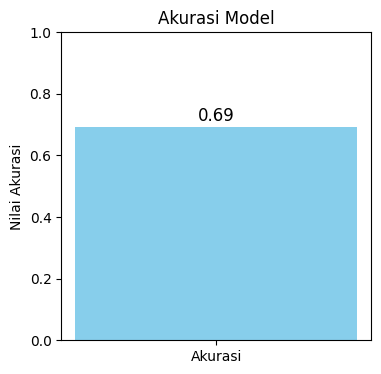

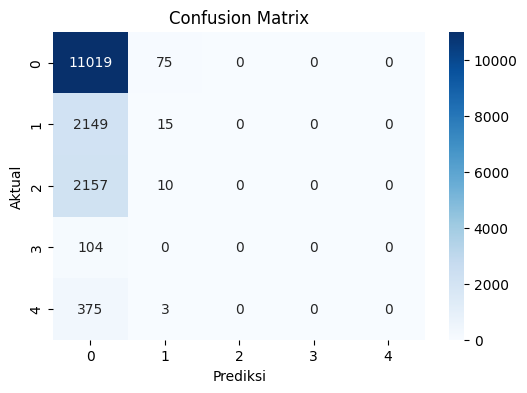

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


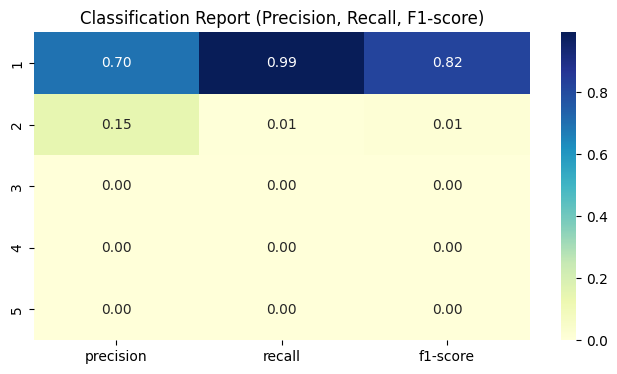

In [ ]:
# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate accuracy
acc = accuracy_score(y_test, y_pred)  # Calculate accuracy and assign to 'acc'

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred) # Calculate confusion matrix and assign to 'cm'


## a. Akurasi Bar Chart
plt.figure(figsize=(4,4))
plt.bar(['Akurasi'], [acc], color='skyblue')
plt.ylim(0,1)
plt.title("Akurasi Model")
plt.ylabel("Nilai Akurasi")
plt.text(0, acc + 0.02, f"{acc:.2f}", ha='center', fontsize=12)
plt.show()

## b. Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

## c. Classification Report Heatmap
report_dict = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_visual = df_report.iloc[:-3, :][['precision', 'recall', 'f1-score']]

plt.figure(figsize=(8,4))
sns.heatmap(df_visual, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Classification Report (Precision, Recall, F1-score)")
plt.show()